##### 10. Distribution and outlier checks

Inspect consumption distributions and IQR outliers for shortlisted NMIs.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Load half-hourly NMI consumption data.
df = pd.read_parquet(Path("../../Datasets/LMS_2013-01-01_2026-03-24_HALF_HOUR_au.pq"))
df = df.drop(columns=["6102507141 consumption", "VAAA003225 consumption"])
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Reuse the shortlist generated by Task/MAST90106 Group 2 EDA.ipynb.
summary_df = pd.read_csv(Path("../EDA_SummaryByNMI.csv"), index_col=0)
summary_df["first date"] = pd.to_datetime(summary_df["first date"])
summary_df["last date"] = pd.to_datetime(summary_df["last date"])
NMI_shortlist = summary_df[((summary_df['Status']=='Active') | (summary_df['Status']=='Mostly Active'))].index
print(f'Number of shortlisted NMIs: {len(NMI_shortlist)}')
NMI_shortlist

Number of shortlisted NMIs: 95


Index(['6102000812', '6102002302', '6102005454', '6102005592', '6102009742',
       '6102009743', '6102009744', '6102023971', '6102038376', '6102046251',
       '6102047562', '6102079015', '6102126219', '6102136796', '6102159807',
       '6102241120', '6102253330', '6102284820', '6102329966', '6102332526',
       '6102479831', '6102548873', '6102573328', '6102798810', '6102823324',
       '6103002422', '6103004482', '6103005867', '6103005869', '6103009639',
       '6103010081', '6103010326', '6103011168', '6103015873', '6103022015',
       '6103022017', '6103022018', '6103029662', '6103029663', '6103031269',
       '6103031796', '6103054578', '6103054611', '6103055142', '6103055392',
       '6103055643', '6103056620', '6103056621', '6103056622', '6103056625',
       '6103063019', '6103063020', '6103065120', '6103065121', '6103065471',
       '6103066694', '6103067996', '6103068525', '6103077259', '6203397519',
       '6203397522', '6203848319', '6203949247', 'VAAA000057', 'VAAA000173',

In [3]:
# Select the active window used in the main EDA summary.
def active_series(nmi):
    variable = f"{nmi} consumption"
    start = summary_df.loc[nmi, "first date"]
    end = summary_df.loc[nmi, "last date"]
    return df.loc[df["date"].between(start, end), ["date", variable]].dropna()

In [4]:
# Identify IQR-rule outliers for one series.
def iqr_outliers(values):
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (values < lower) | (values > upper), lower, upper

In [5]:
# Count consecutive half-hour outlier runs.
def max_run(dates):
    if dates.empty:
        return 0
    groups = dates.diff().div(pd.Timedelta(minutes=30)).ne(1).cumsum()
    return groups.value_counts().max()

In [6]:
# Summarise distribution shape and IQR outliers.
rows = []

for nmi in NMI_shortlist:
    variable = f"{nmi} consumption"
    data = active_series(nmi)
    values = data[variable]
    mask, lower, upper = iqr_outliers(values)
    outlier_dates = data.loc[mask, "date"]
    outlier_count = mask.sum()
    outlier_pct = outlier_count / len(values) * 100
    skew = values.skew()
    run = max_run(outlier_dates)
    month = outlier_dates.dt.to_period("M").value_counts().idxmax() if outlier_count else pd.NA

    rows.append([
        nmi,
        "right-skewed" if skew > 1 else "balanced",
        outlier_count,
        round(outlier_pct, 2),
        round(lower, 3),
        round(upper, 3),
        run,
        str(month) if outlier_count else pd.NA,
        "clustered" if run > 1 else "isolated",
        "substantial" if outlier_pct >= 5 else "moderate" if outlier_pct >= 1 else "few",
    ])

outlier_table = pd.DataFrame(rows, columns=[
    "NMI", "shape", "outlier_count", "outlier_pct", "iqr_lower", "iqr_upper",
    "max_outlier_run", "main_outlier_month", "outlier_pattern", "outlier_level"
])
outlier_table

,NMI,shape,outlier_count,outlier_pct,iqr_lower,iqr_upper,max_outlier_run,main_outlier_month,outlier_pattern,outlier_level
0,6102000812,right-skewed,5778,2.49,0.288,52.256,96,2015-07,clustered,moderate
1,6102002302,right-skewed,24356,10.51,-9.800,43.320,22,2019-01,clustered,substantial
2,6102005454,balanced,6161,2.66,18.000,110.800,96,2014-08,clustered,moderate
3,6102005592,right-skewed,8671,3.74,-80.050,167.070,79,2019-01,clustered,moderate
4,6102009742,balanced,3645,1.57,2.248,10.888,96,2015-08,clustered,moderate
...,...,...,...,...,...,...,...,...,...,...
90,VAAA004066,right-skewed,2483,11.57,0.308,0.340,350,2025-06,clustered,substantial
91,VCCCAE0035,balanced,19390,8.36,64.400,180.752,96,2018-01,clustered,substantial
92,VCCCBC0096,balanced,10913,4.71,5.280,49.920,96,2026-01,clustered,moderate
93,VCCCSC0045,balanced,2729,1.18,-21.165,72.155,24,2019-01,clustered,moderate


In [7]:
# Compact interpretation per NMI.
interpretation = outlier_table[["NMI", "shape", "outlier_level", "outlier_pattern", "main_outlier_month"]]
interpretation

,NMI,shape,outlier_level,outlier_pattern,main_outlier_month
0,6102000812,right-skewed,moderate,clustered,2015-07
1,6102002302,right-skewed,substantial,clustered,2019-01
2,6102005454,balanced,moderate,clustered,2014-08
3,6102005592,right-skewed,moderate,clustered,2019-01
4,6102009742,balanced,moderate,clustered,2015-08
...,...,...,...,...,...
90,VAAA004066,right-skewed,substantial,clustered,2025-06
91,VCCCAE0035,balanced,substantial,clustered,2018-01
92,VCCCBC0096,balanced,moderate,clustered,2026-01
93,VCCCSC0045,balanced,moderate,clustered,2019-01


In [8]:
# Overall outlier profile across shortlisted NMIs.
outlier_table[["shape", "outlier_level", "outlier_pattern"]].value_counts().reset_index(name="nmi_count")

,shape,outlier_level,outlier_pattern,nmi_count
0,balanced,moderate,clustered,25
1,balanced,few,clustered,23
2,right-skewed,moderate,clustered,22
3,right-skewed,substantial,clustered,15
4,balanced,few,isolated,5
5,right-skewed,few,clustered,3
6,balanced,substantial,clustered,2


In [9]:
# Plot histogram and boxplot for one NMI.
def plot_distribution(nmi):
    variable = f"{nmi} consumption"
    data = active_series(nmi)
    values = data[variable]

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].hist(values, bins=50)
    axes[0].set_title(f"{nmi} histogram")
    axes[0].set_xlabel("consumption")
    axes[0].set_ylabel("count")
    axes[1].boxplot(values, vert=False)
    axes[1].set_title(f"{nmi} boxplot")
    axes[1].set_xlabel("consumption")
    plt.tight_layout()
    return fig

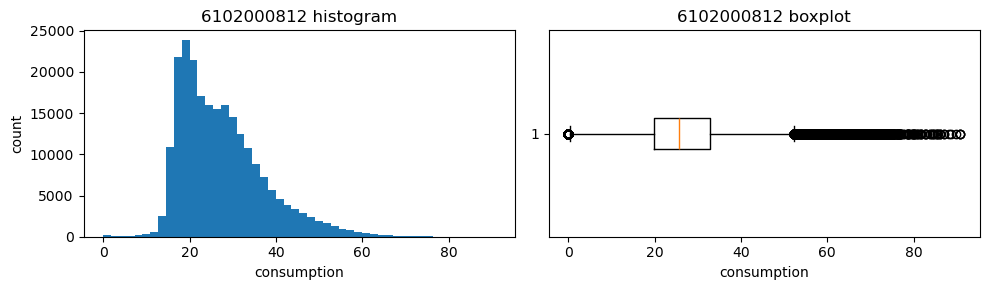

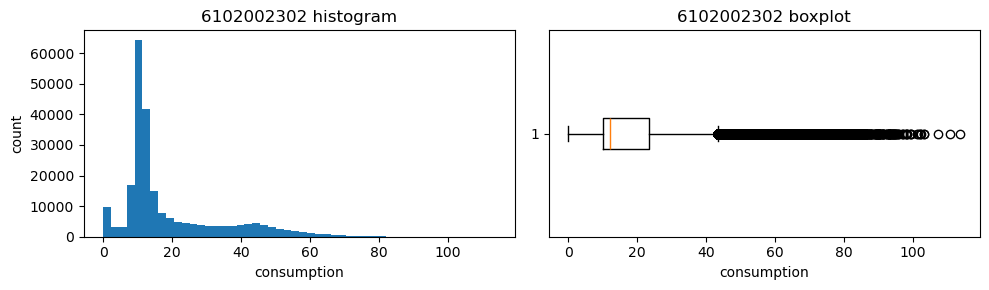

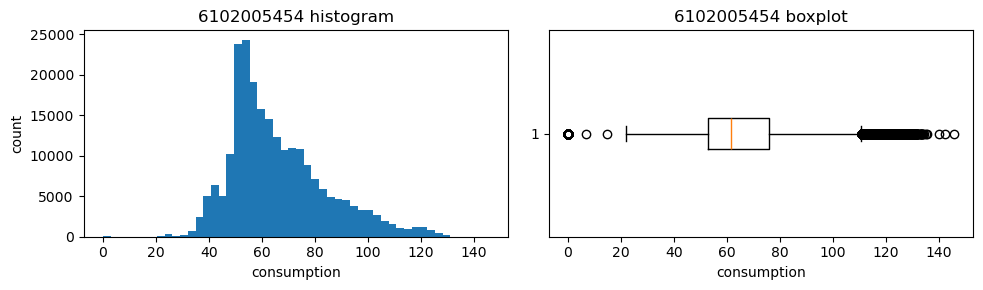

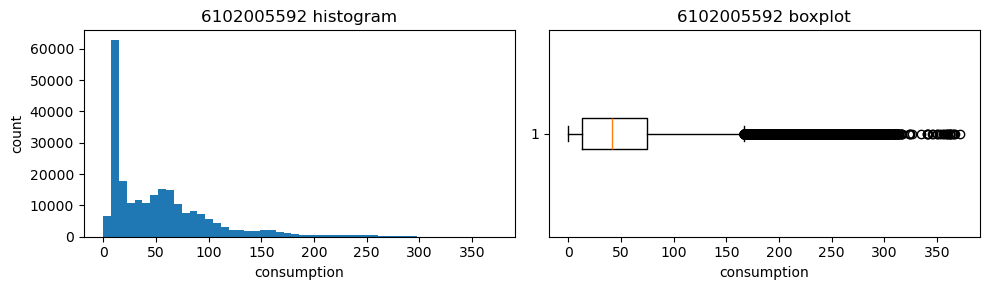

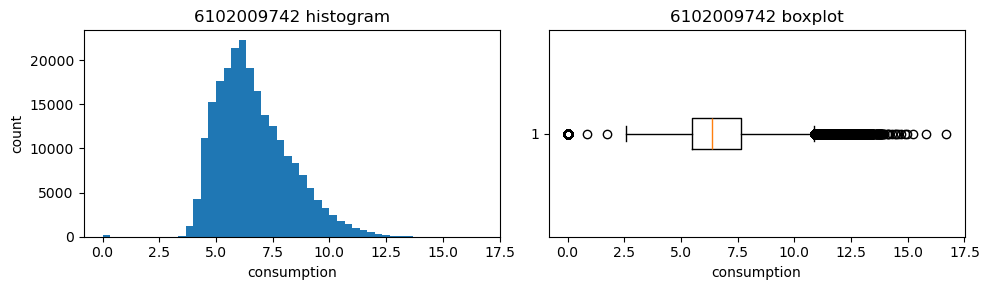

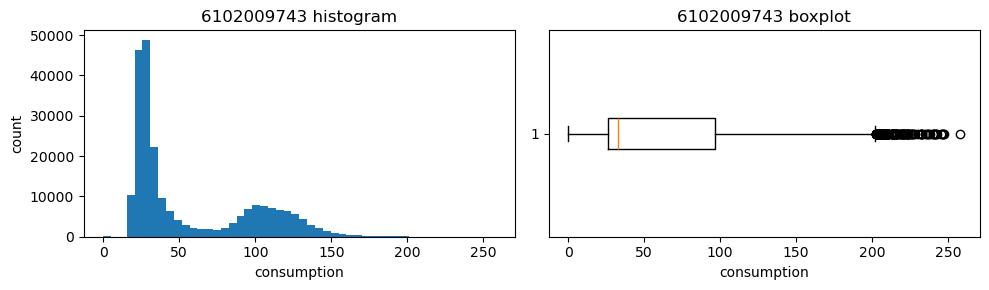

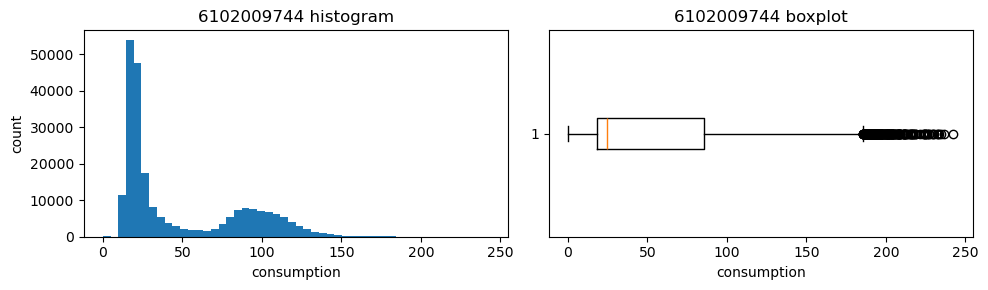

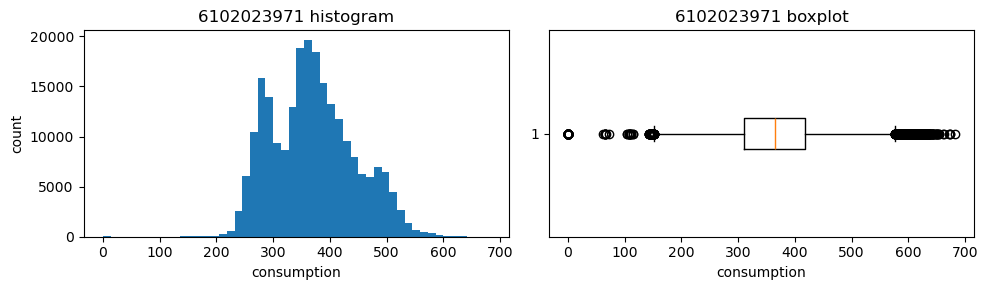

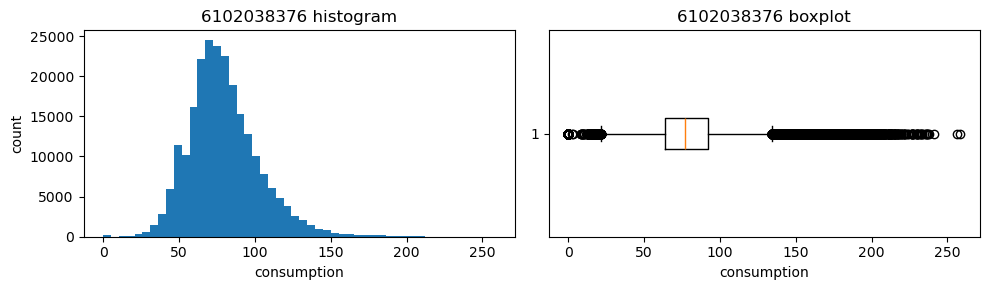

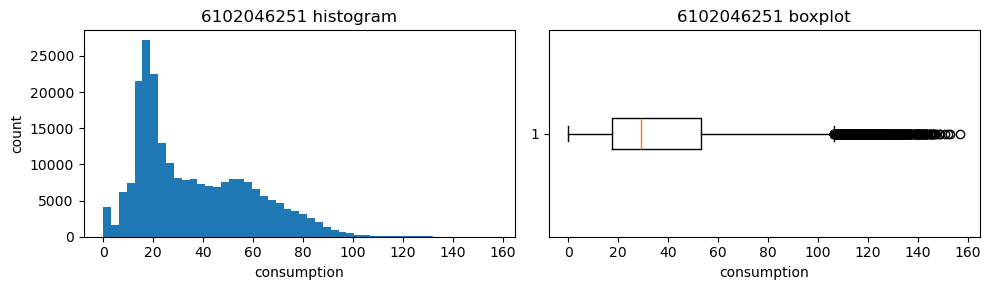

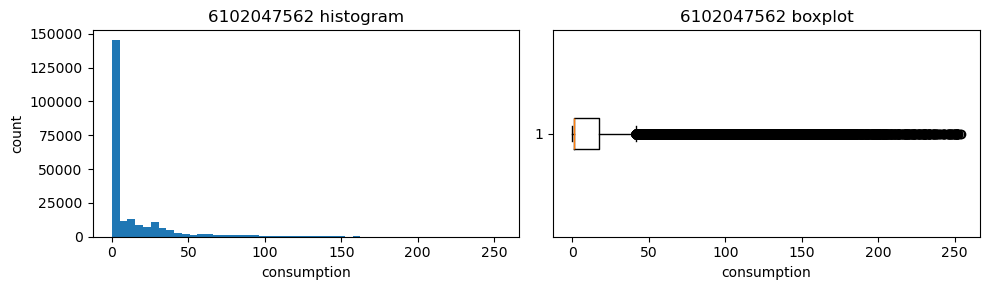

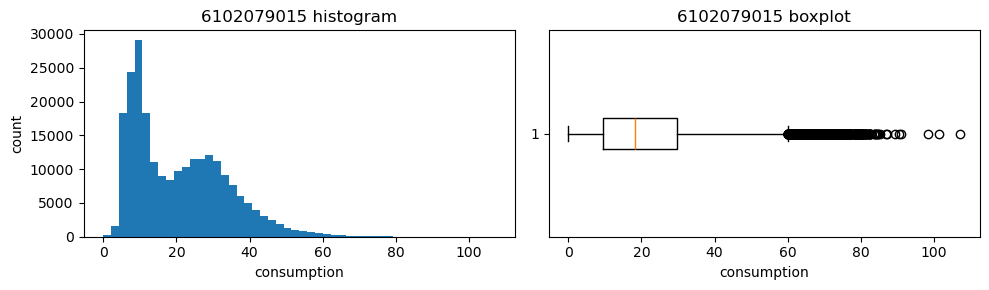

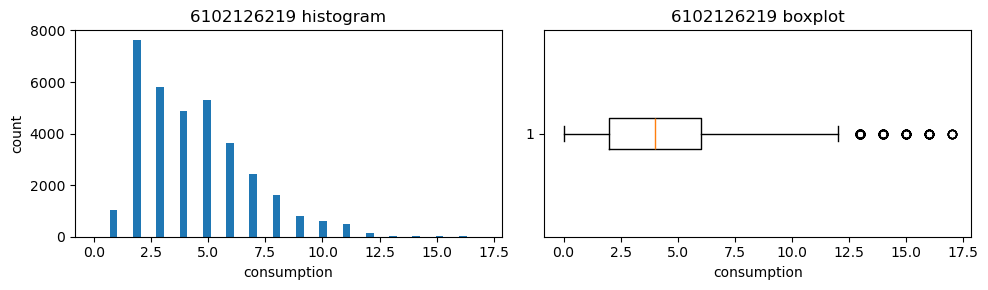

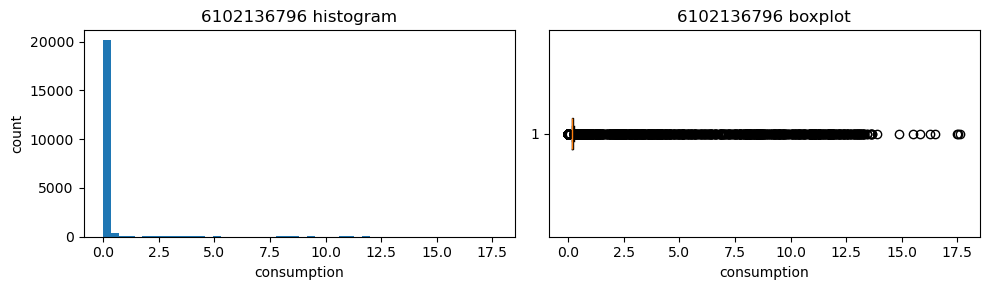

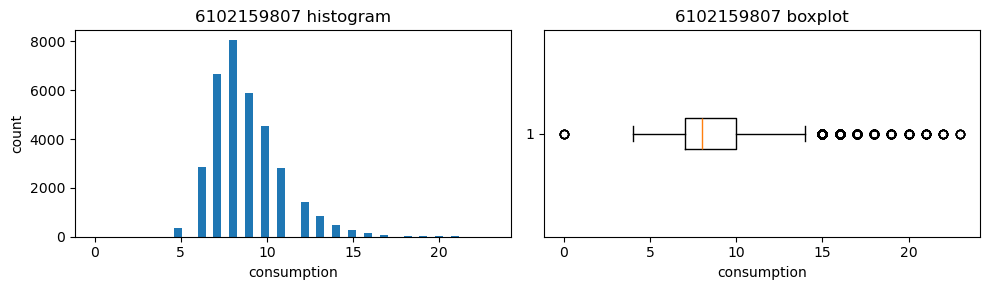

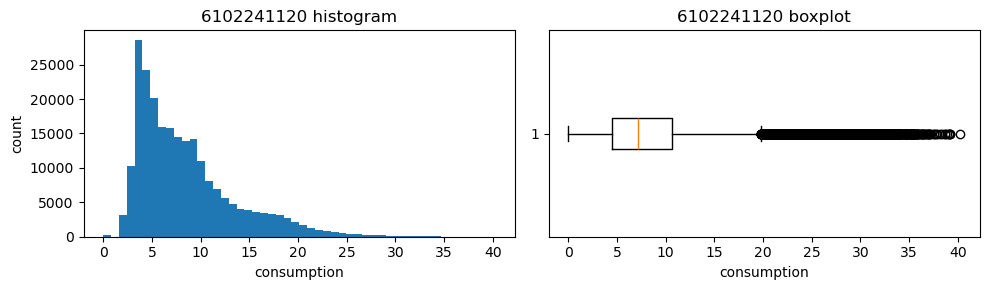

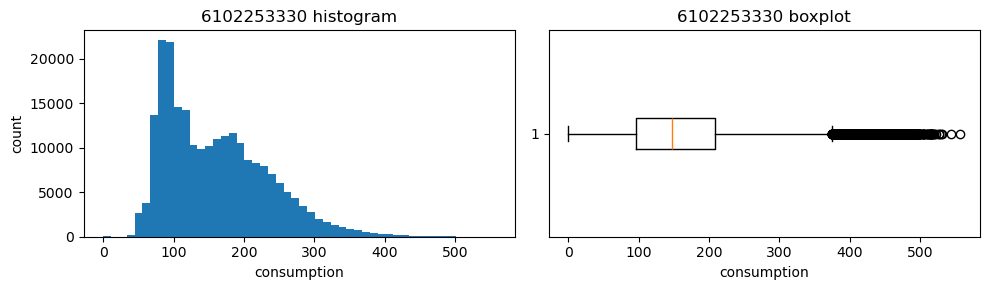

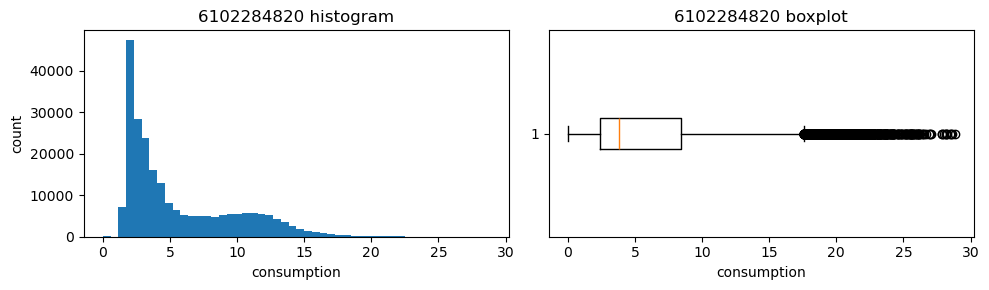

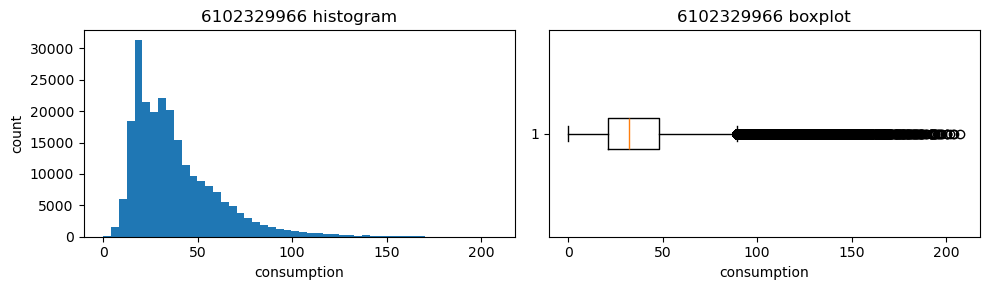

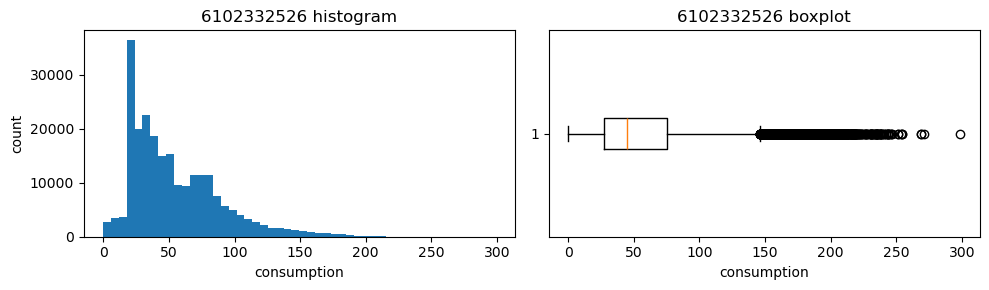

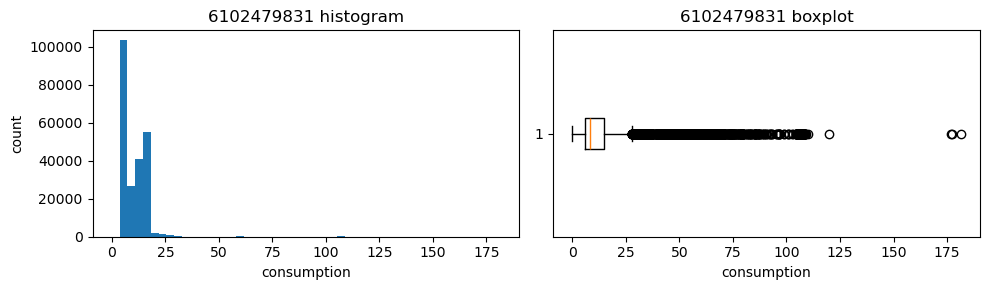

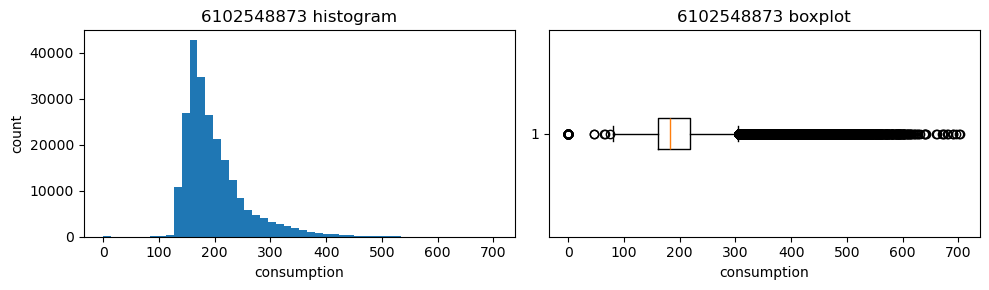

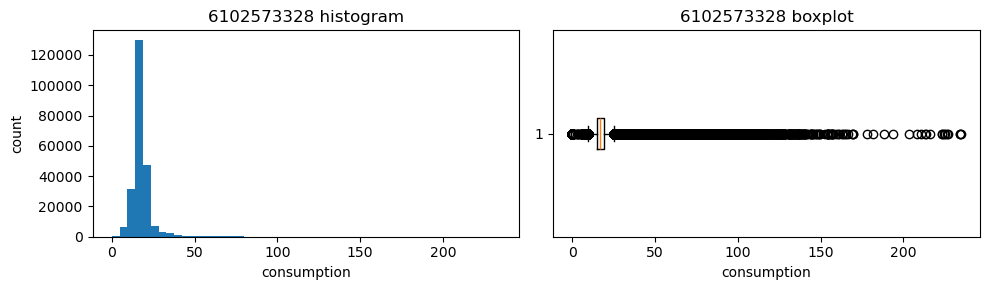

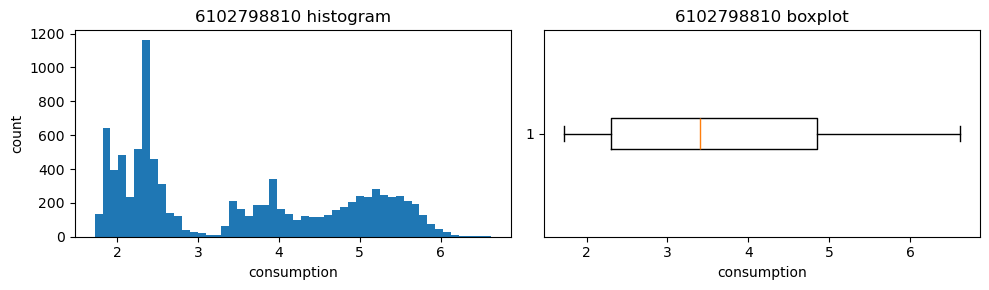

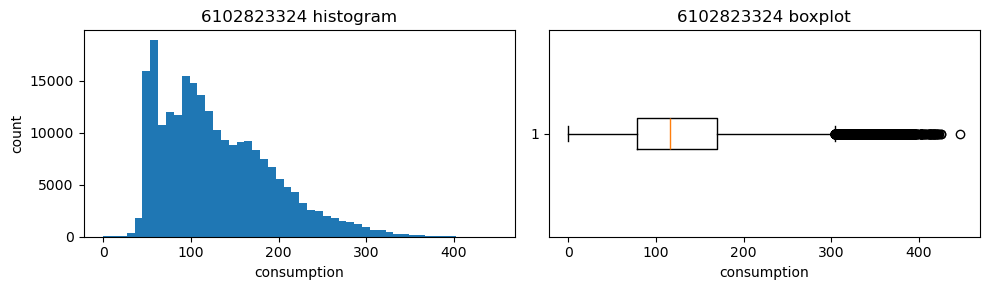

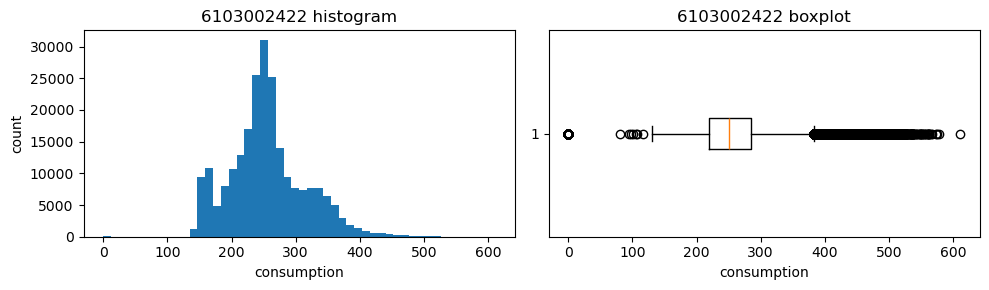

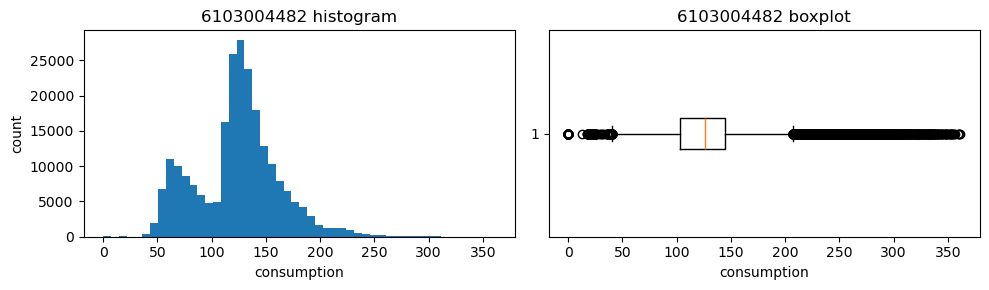

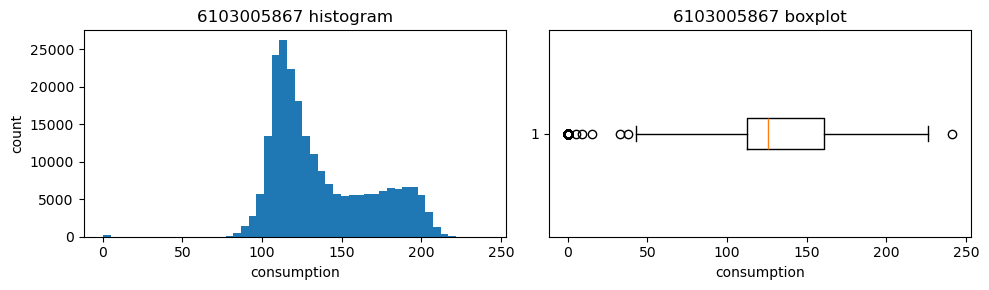

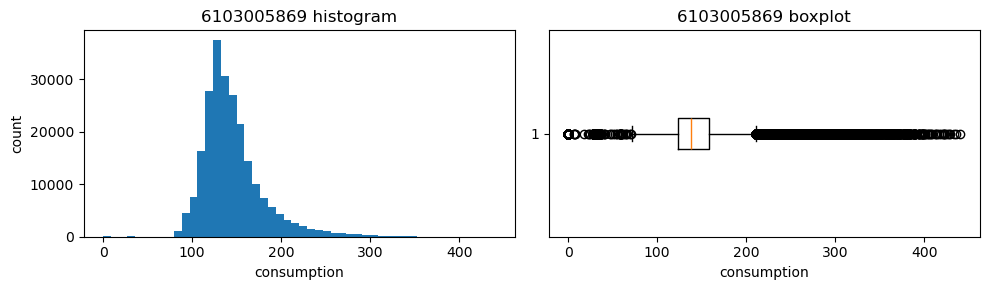

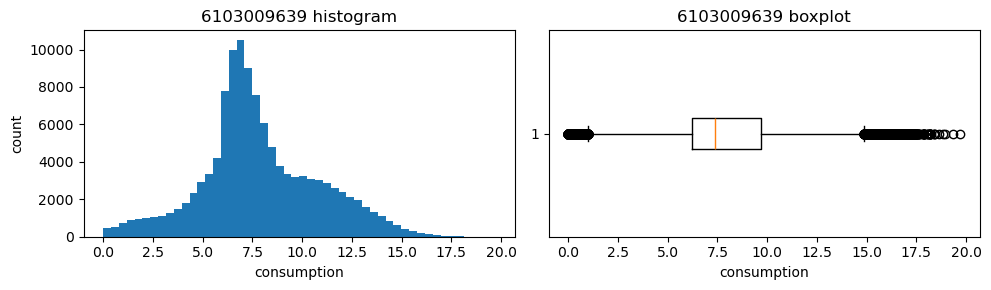

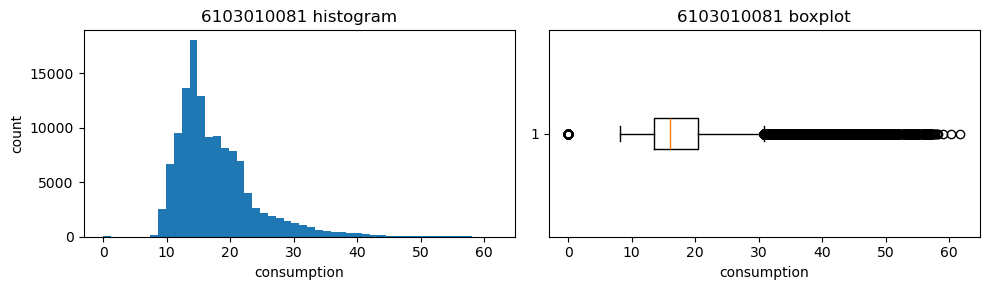

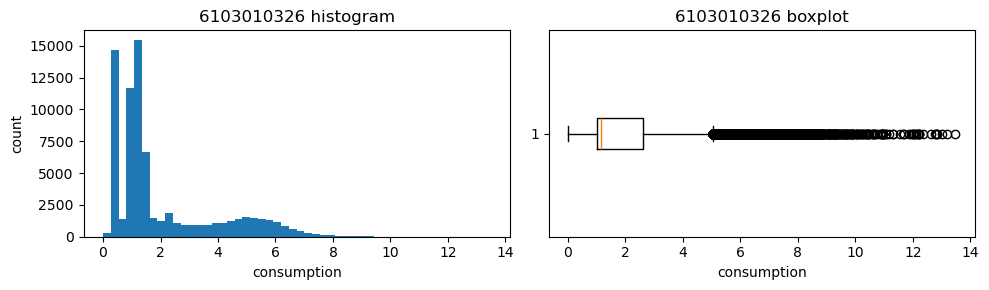

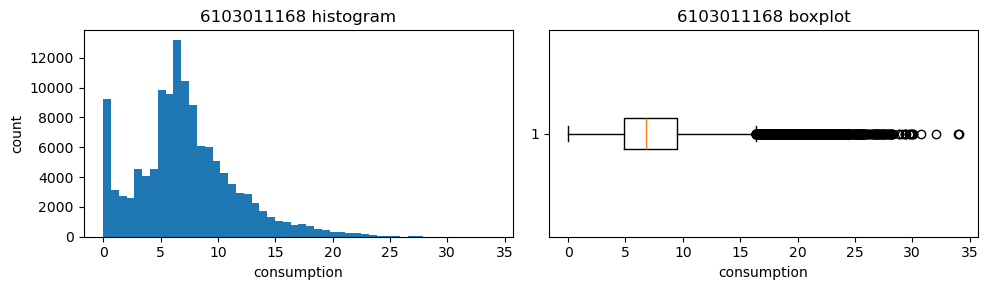

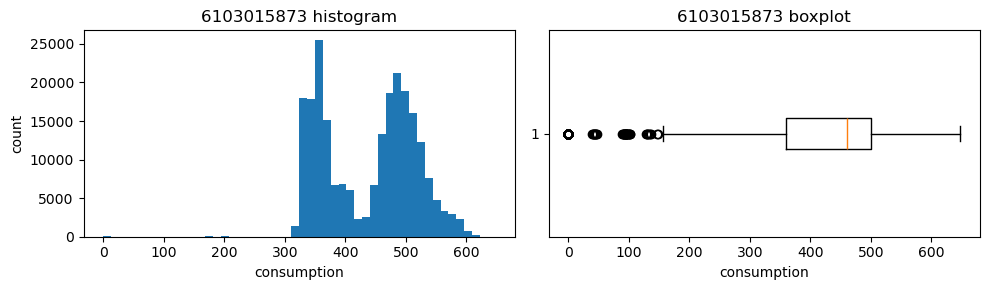

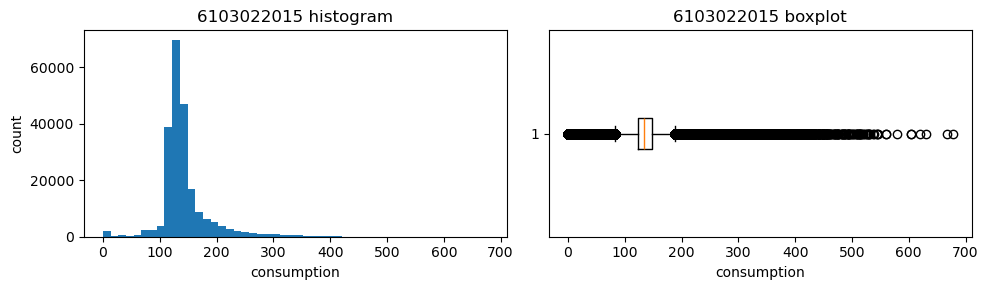

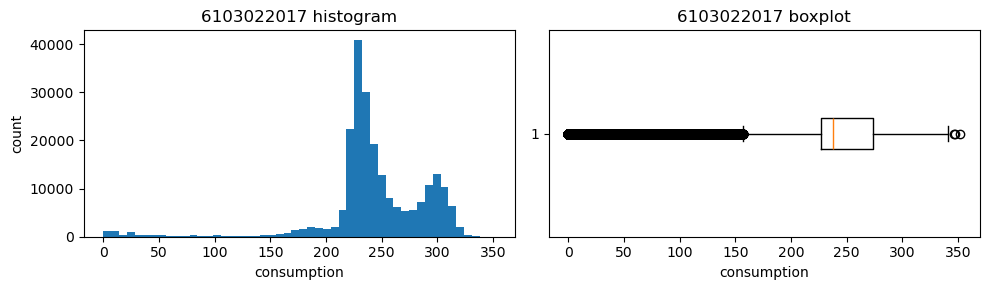

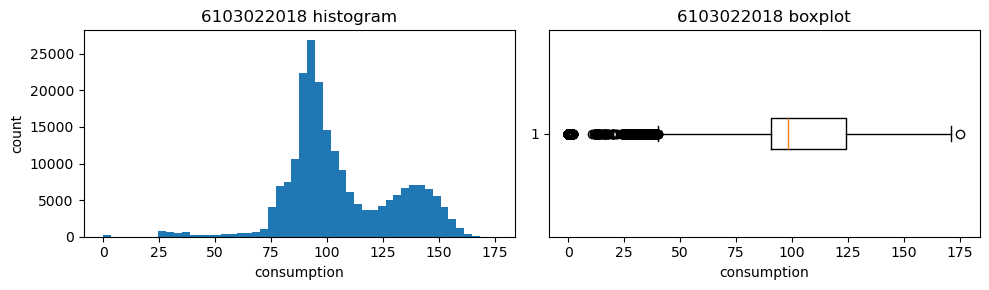

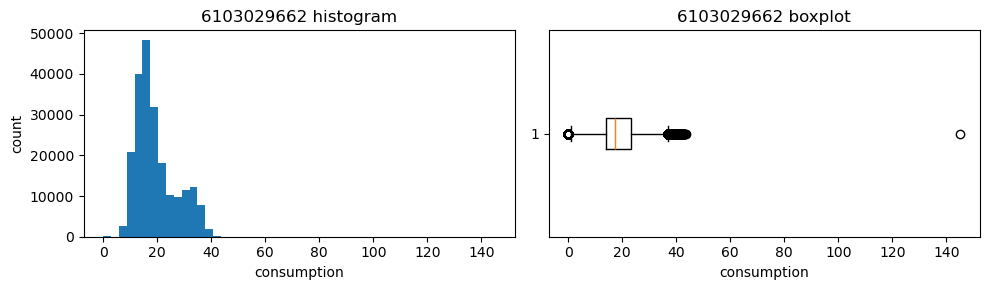

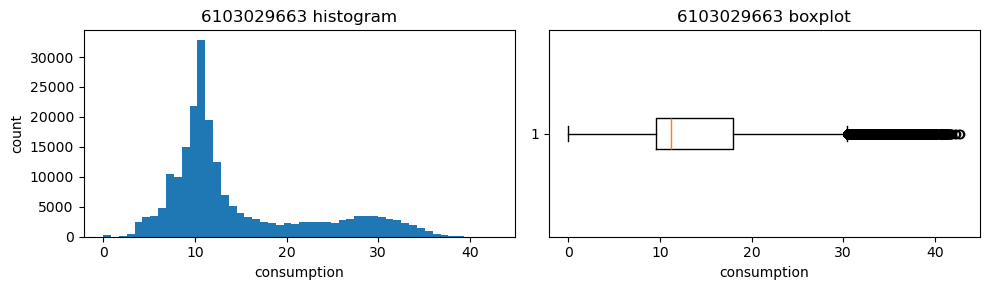

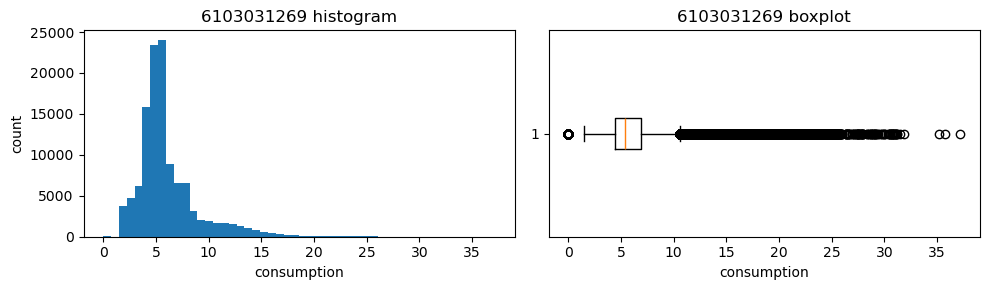

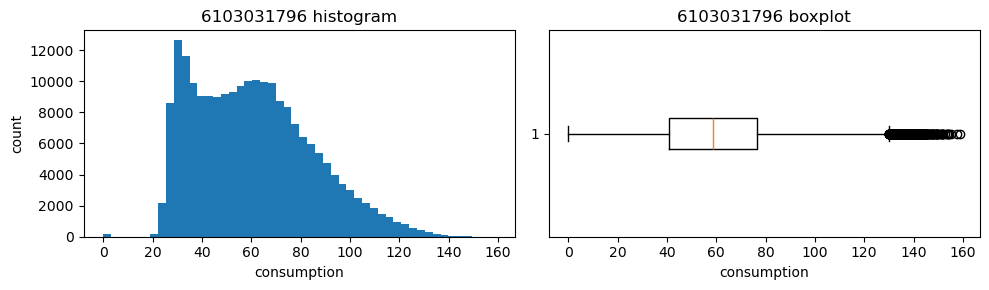

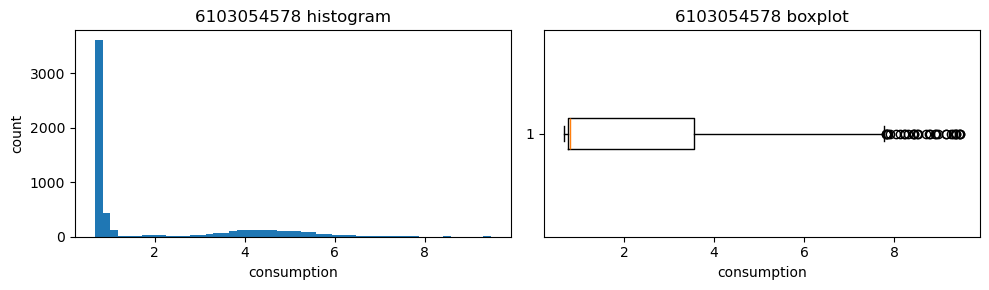

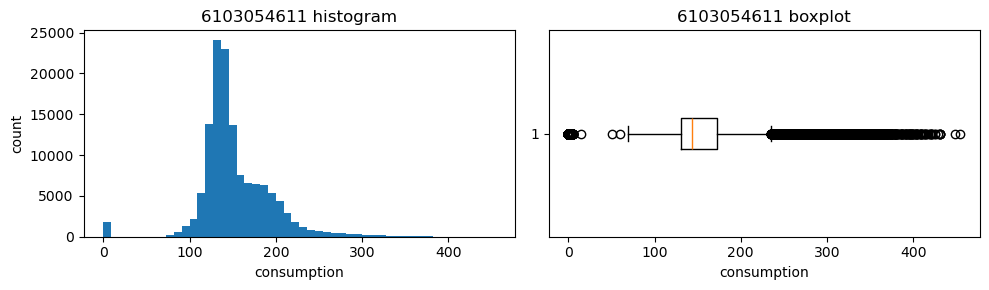

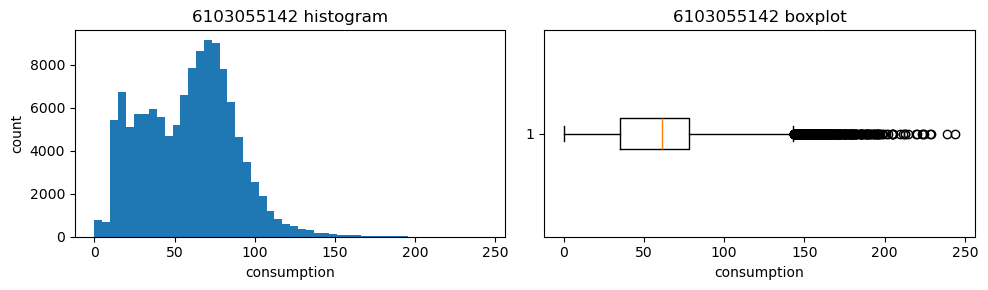

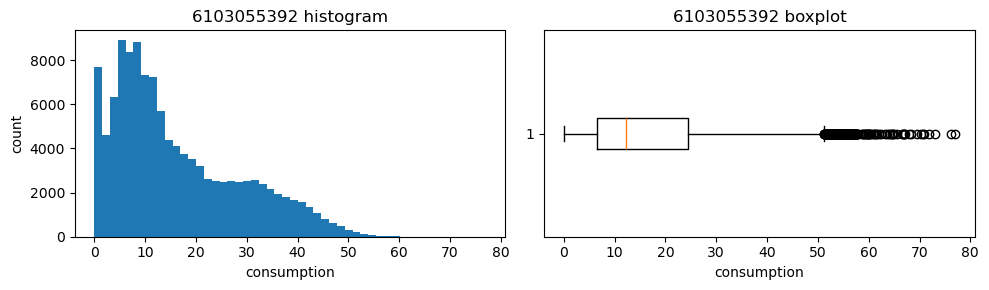

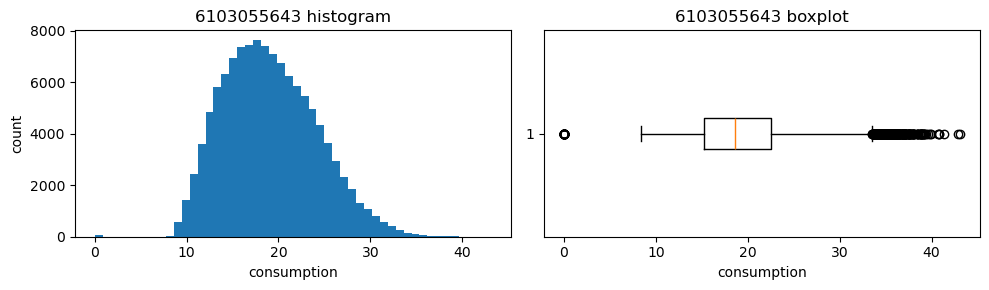

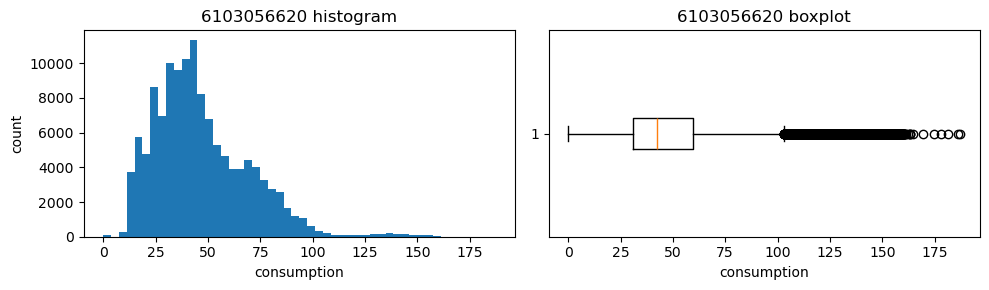

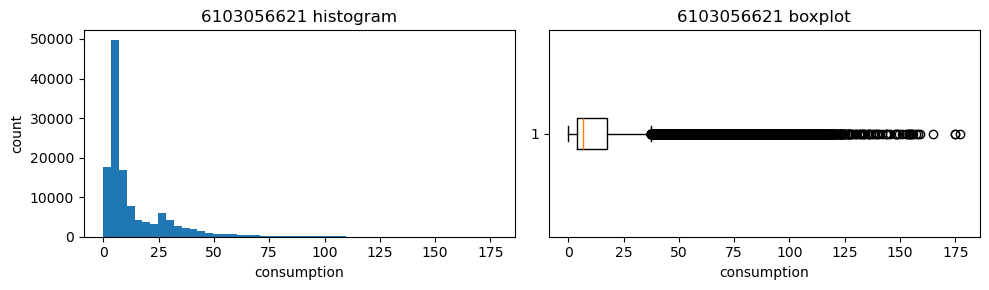

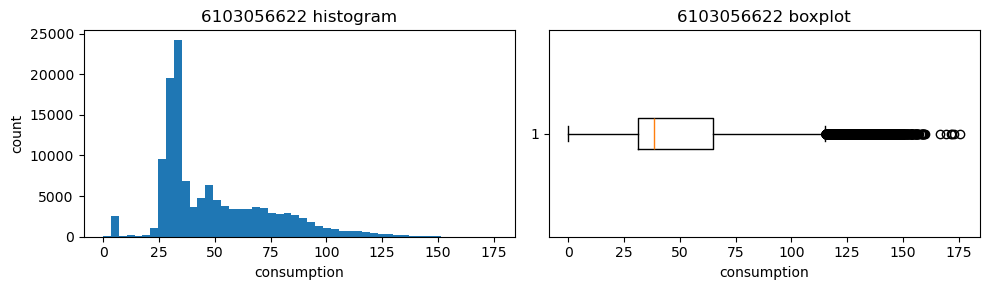

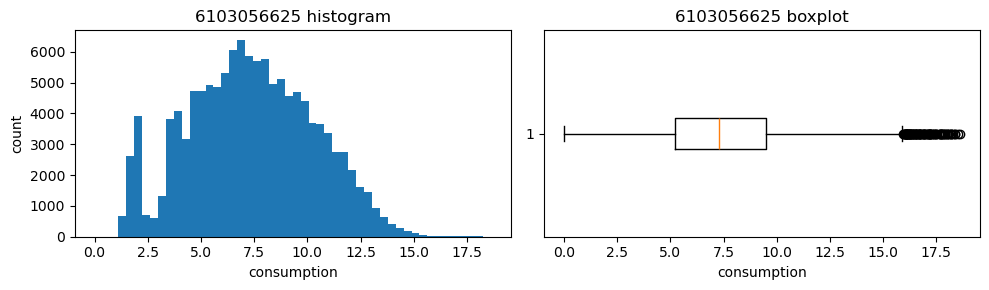

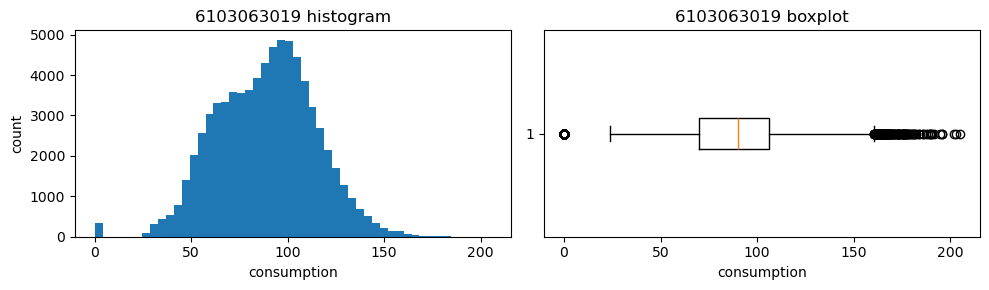

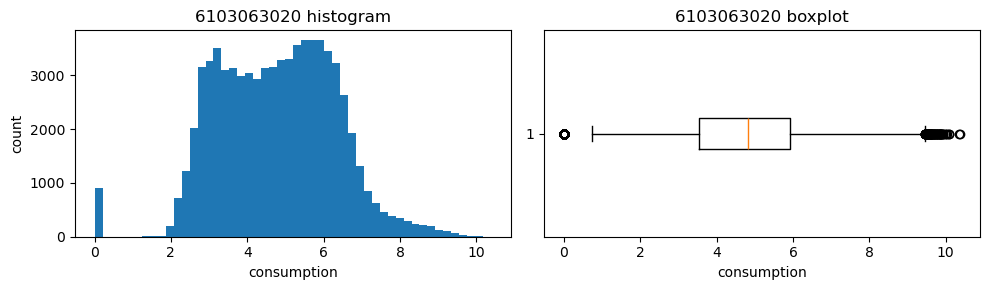

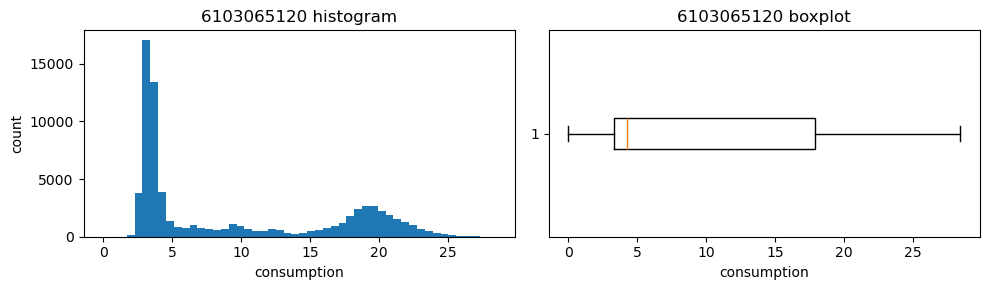

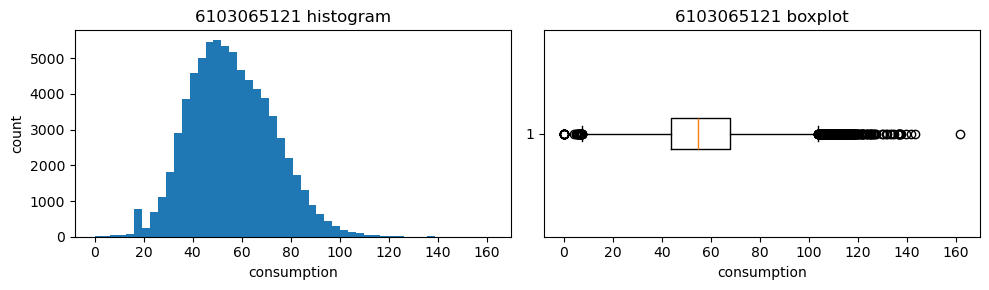

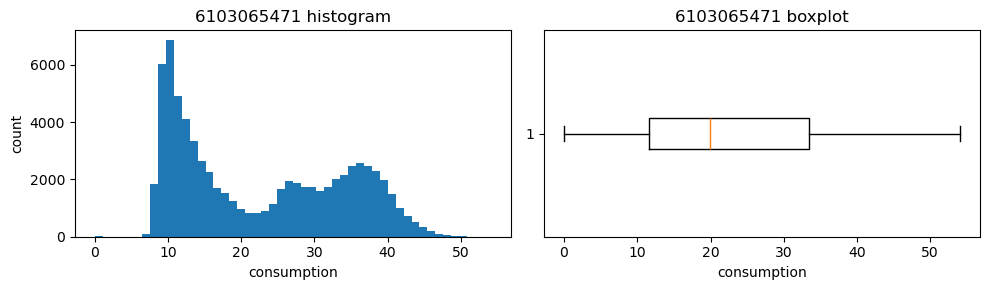

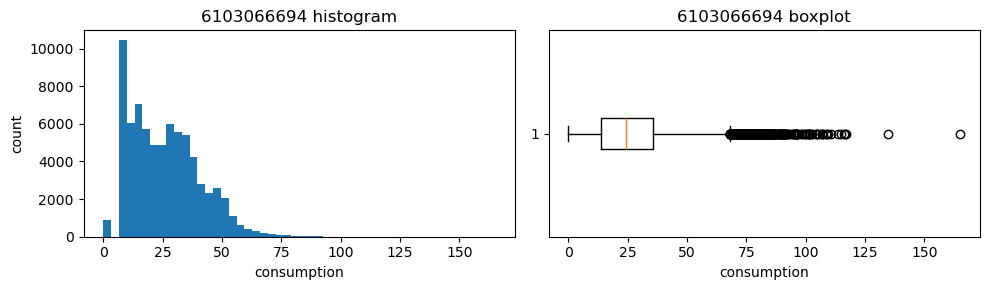

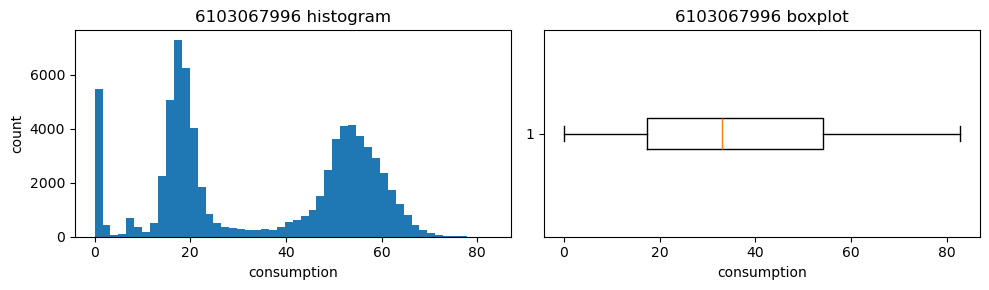

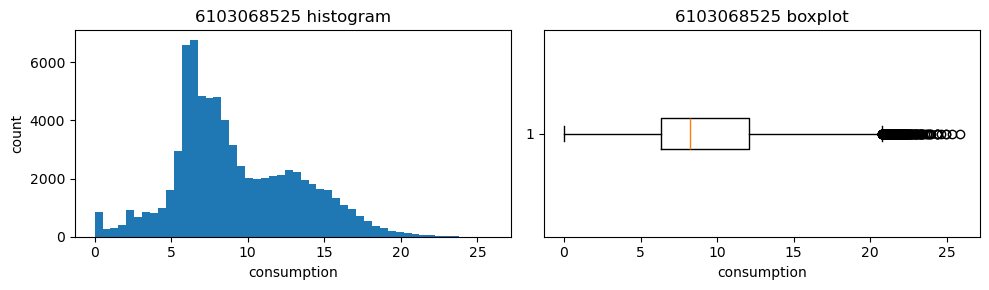

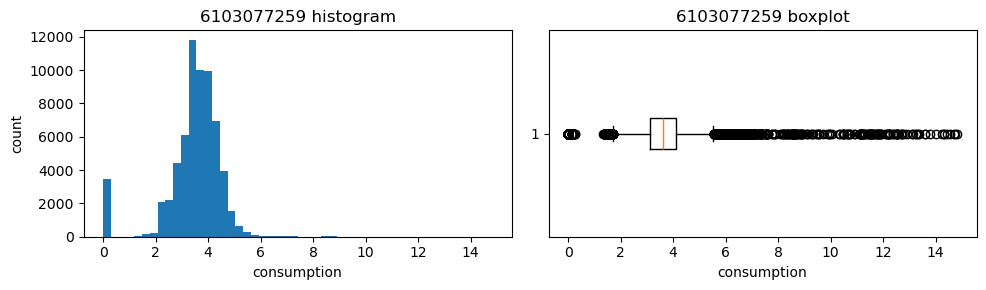

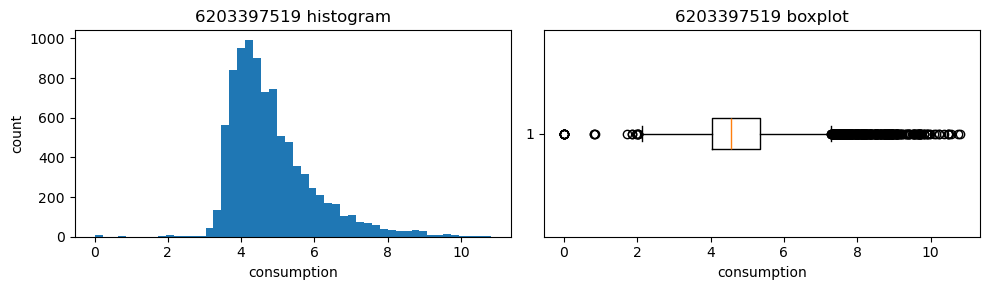

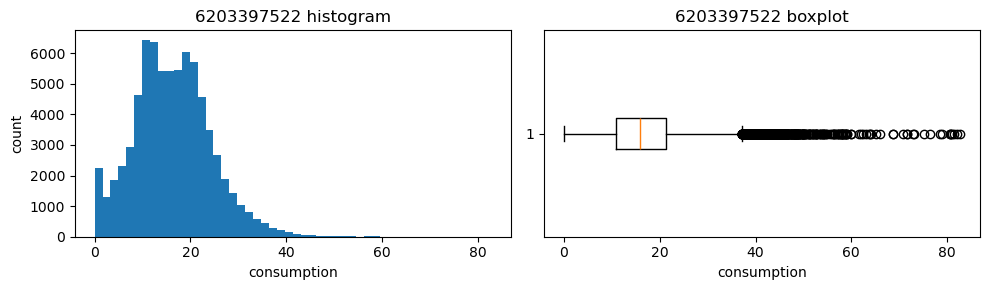

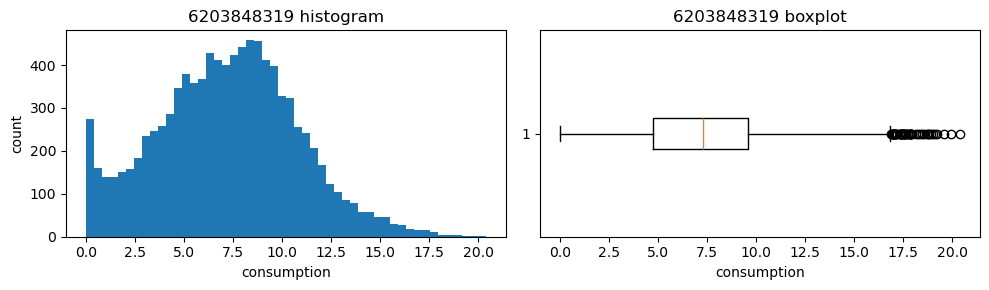

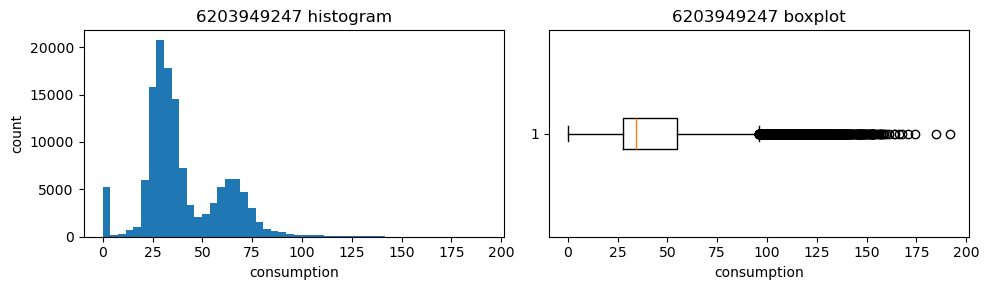

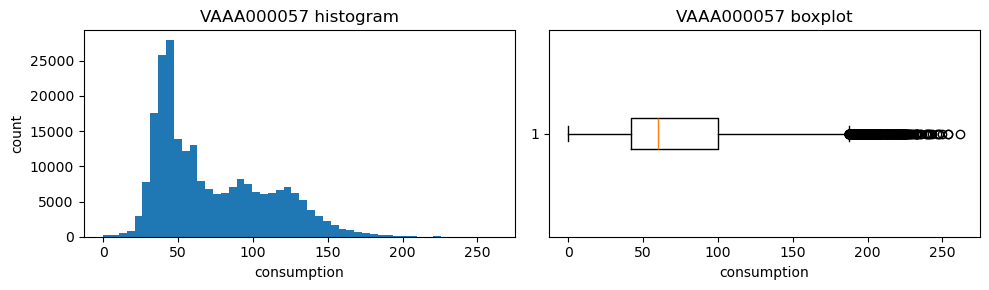

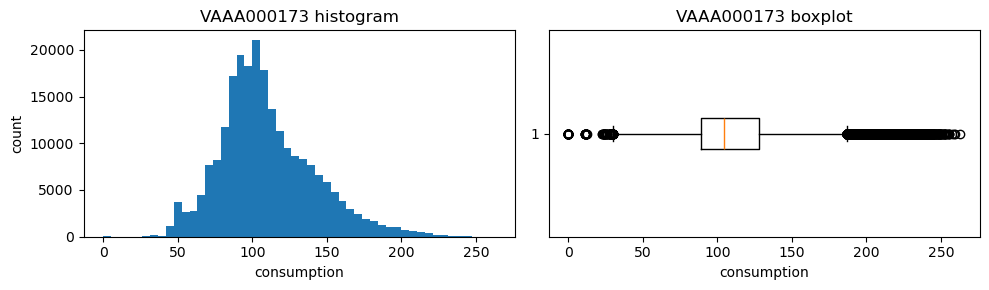

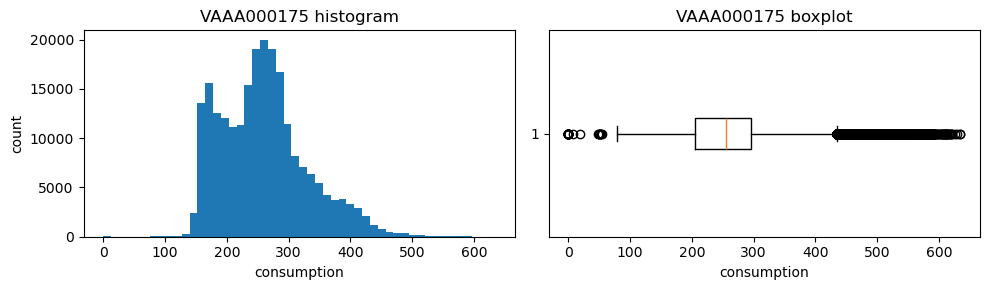

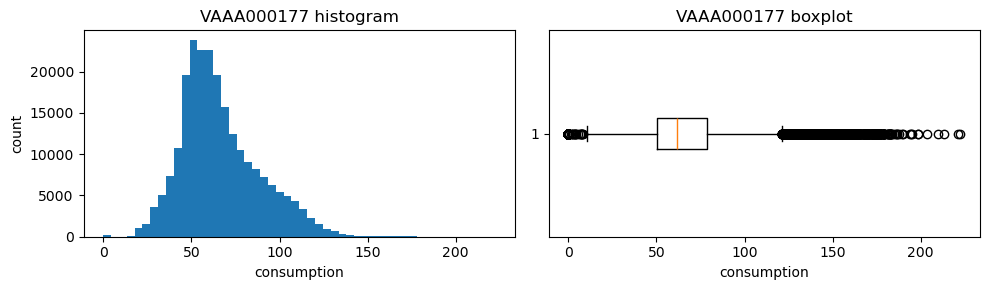

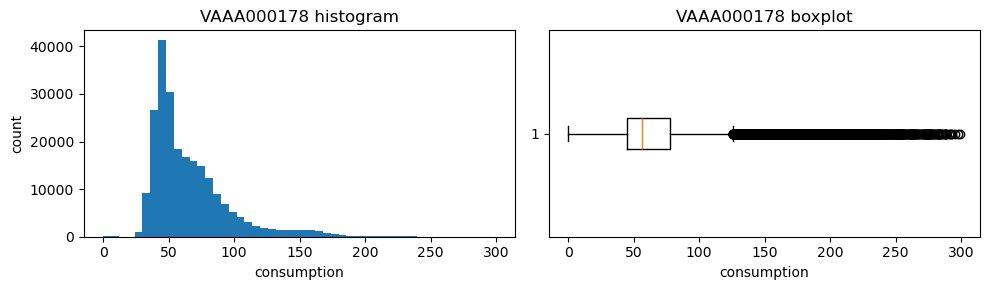

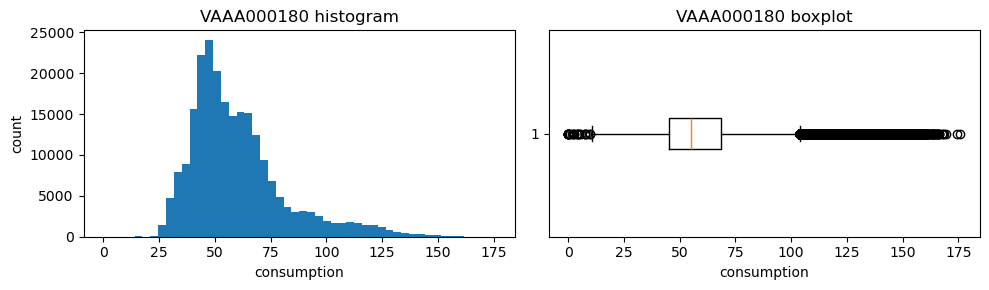

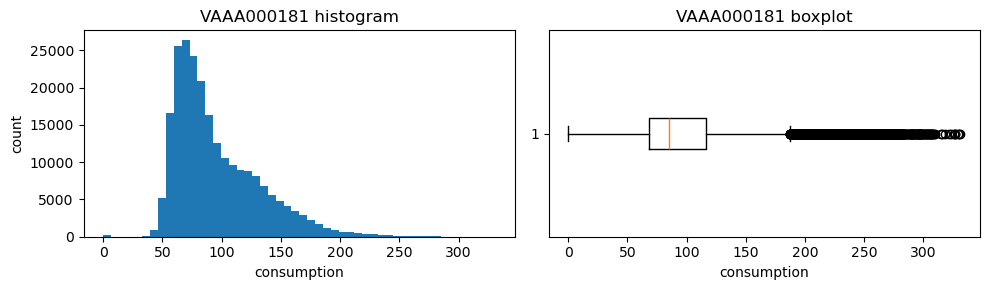

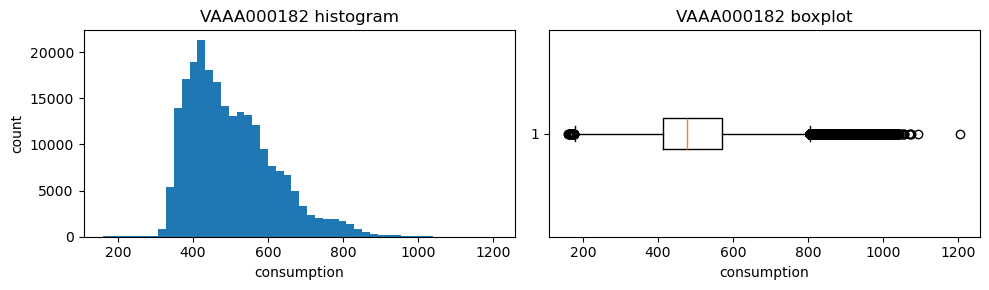

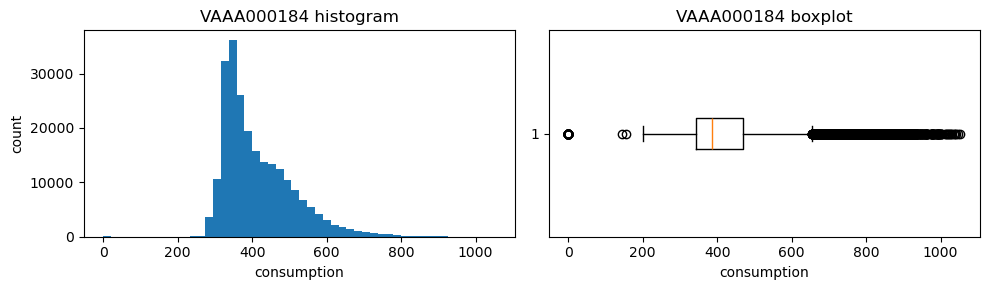

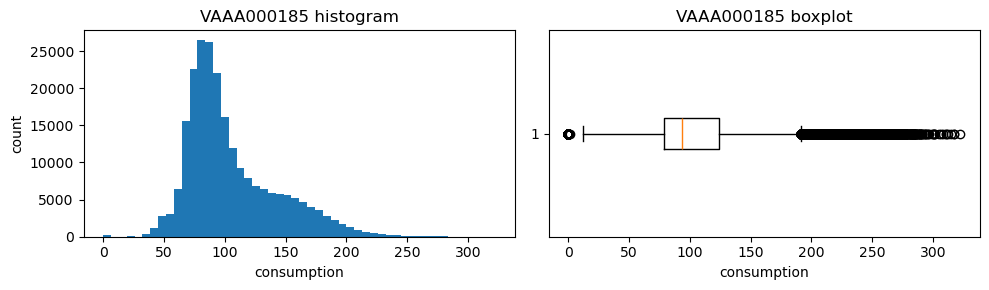

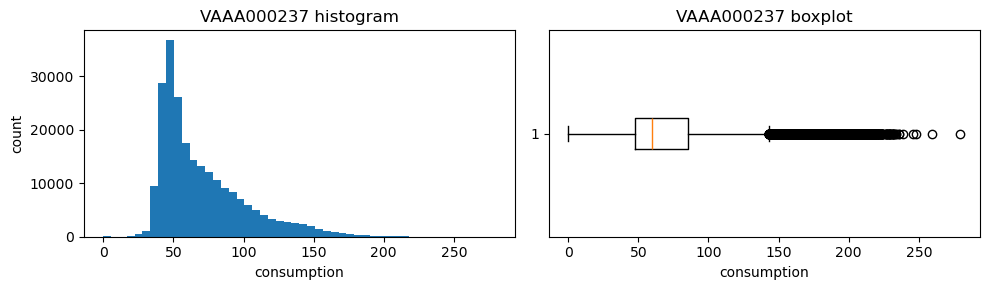

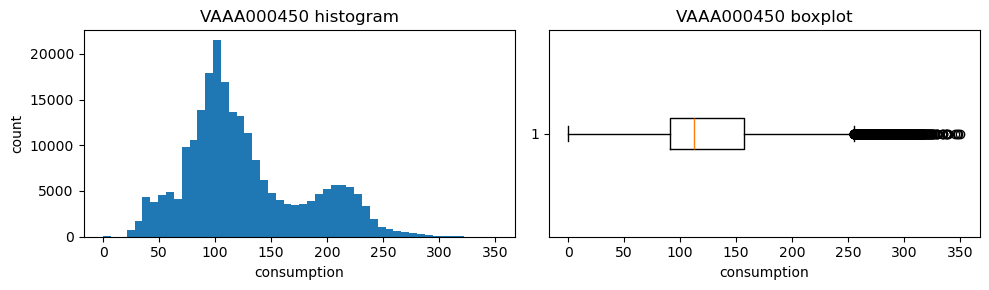

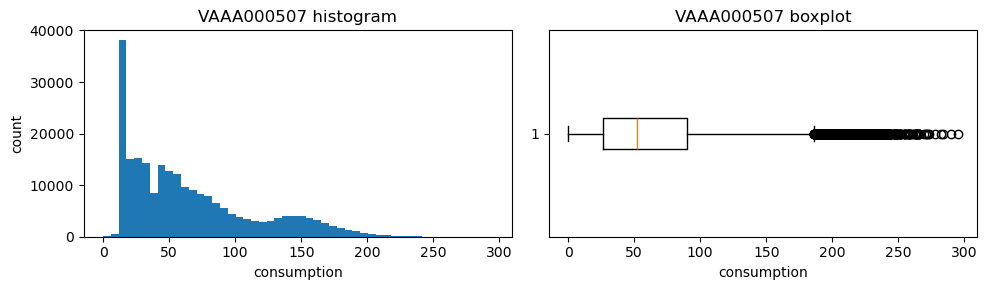

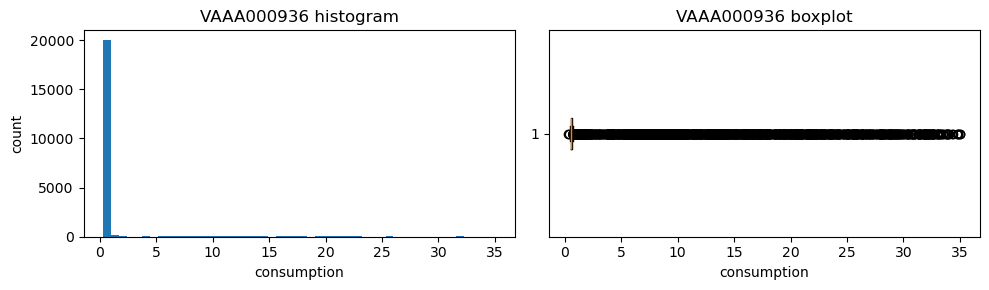

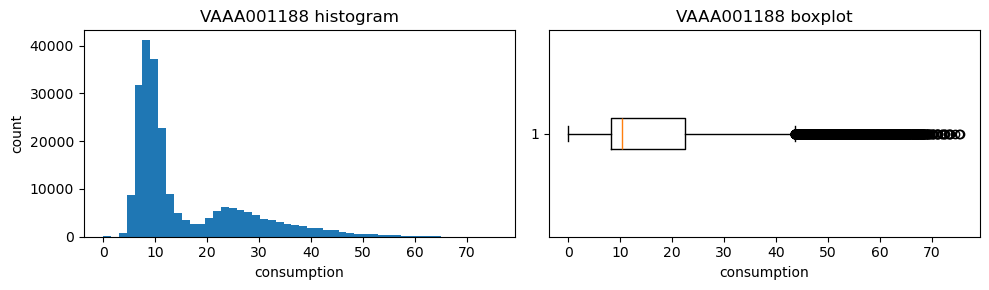

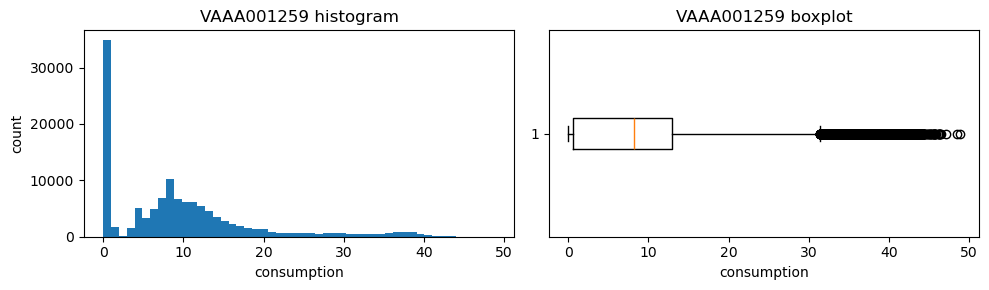

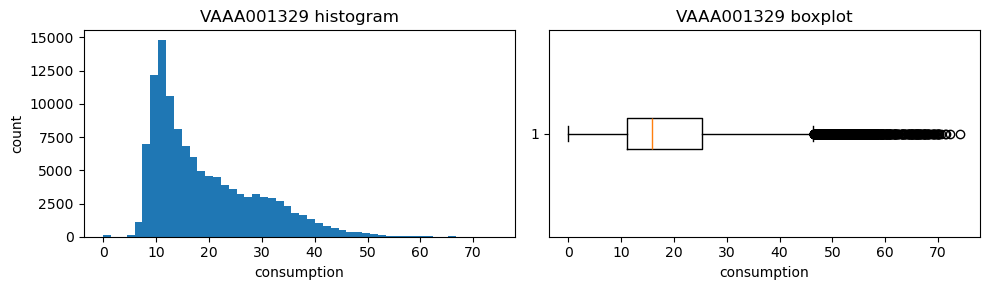

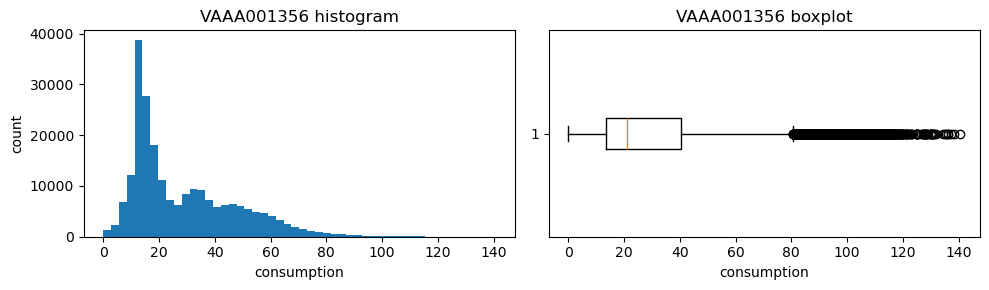

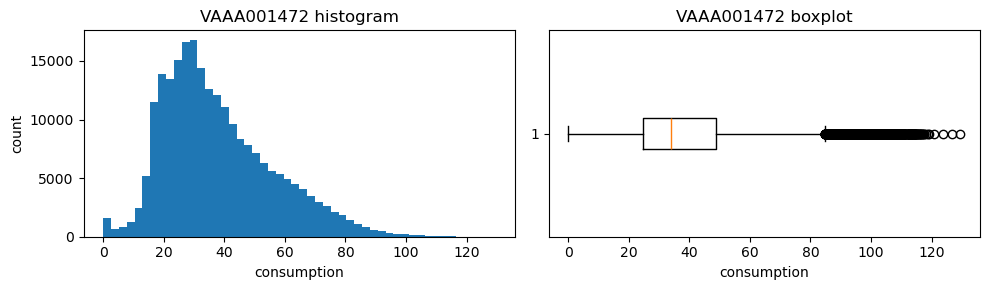

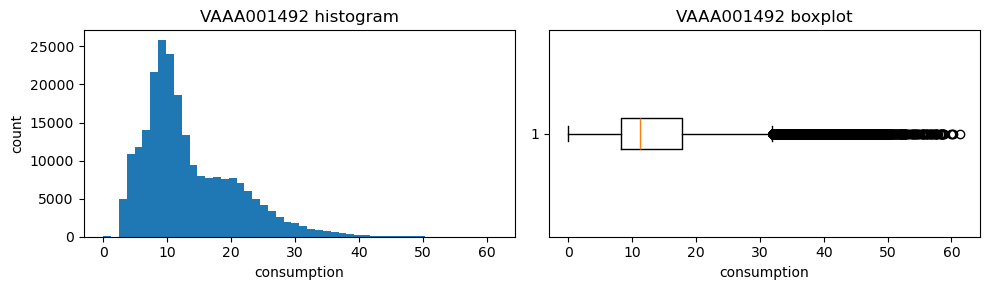

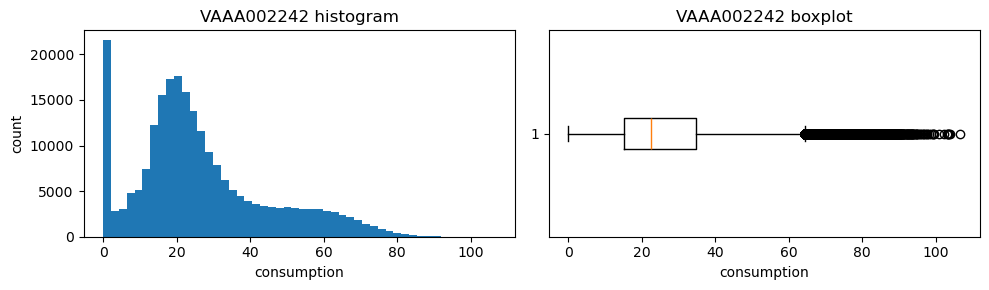

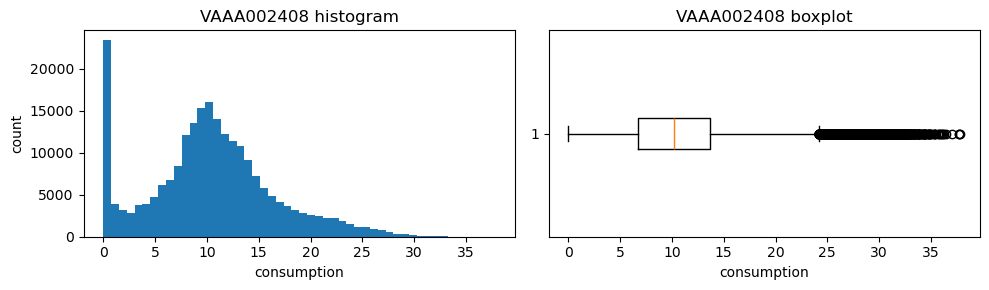

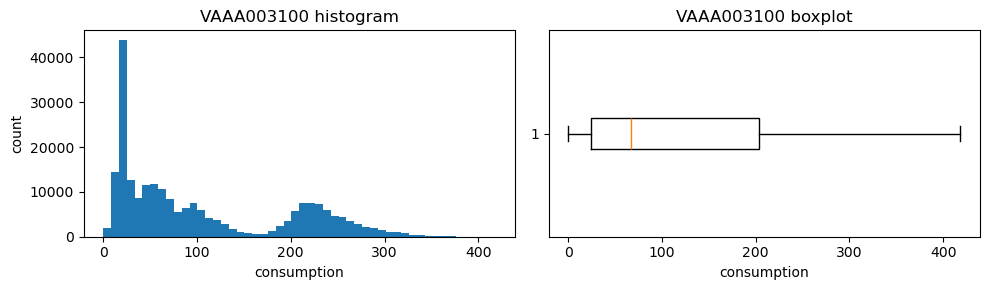

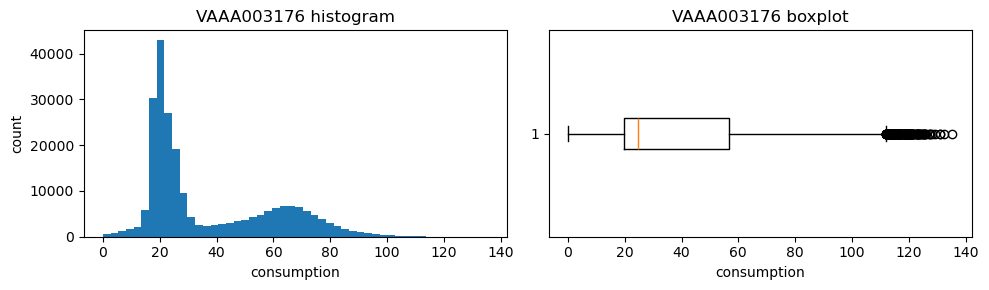

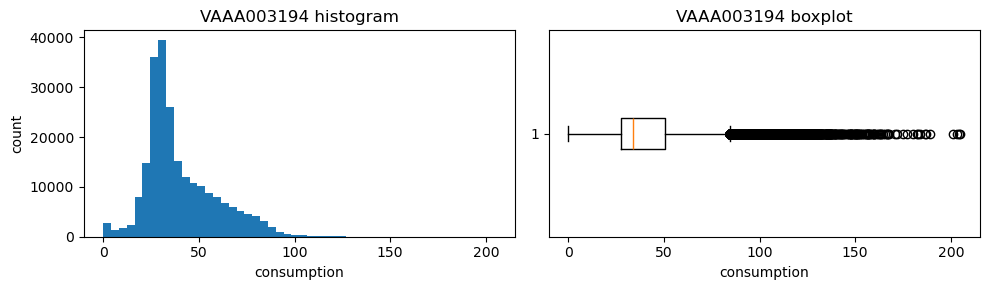

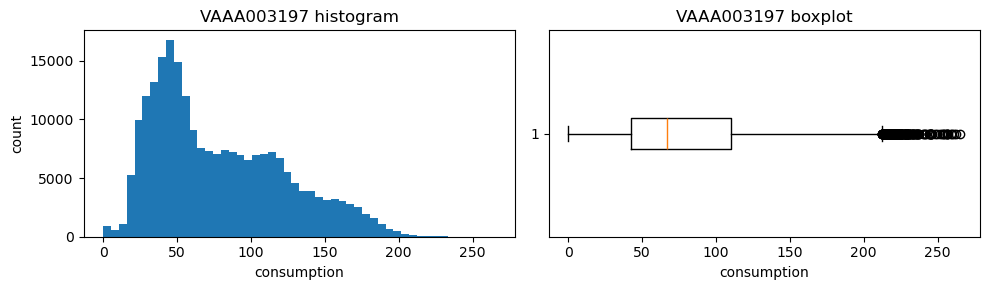

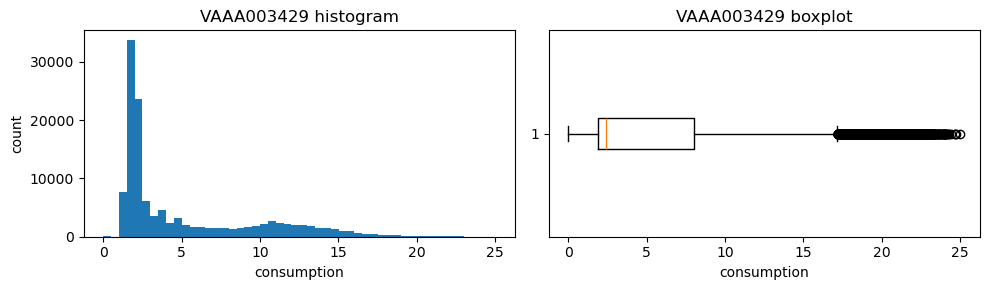

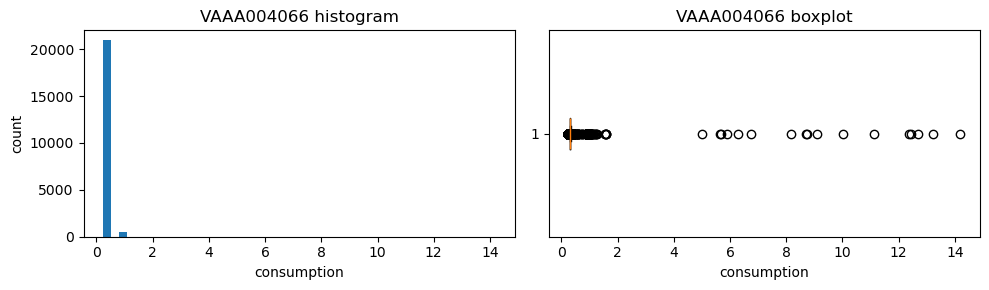

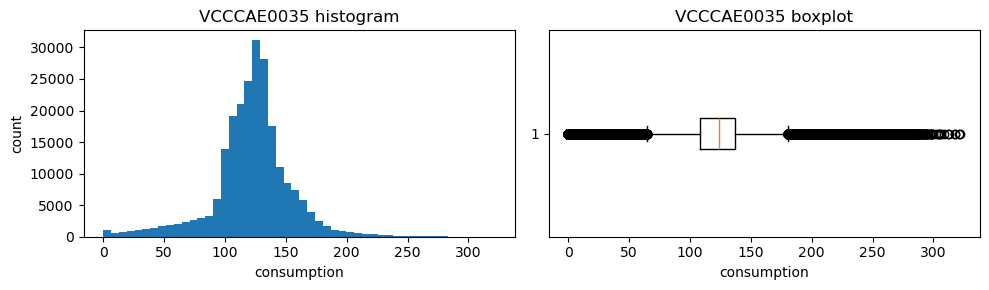

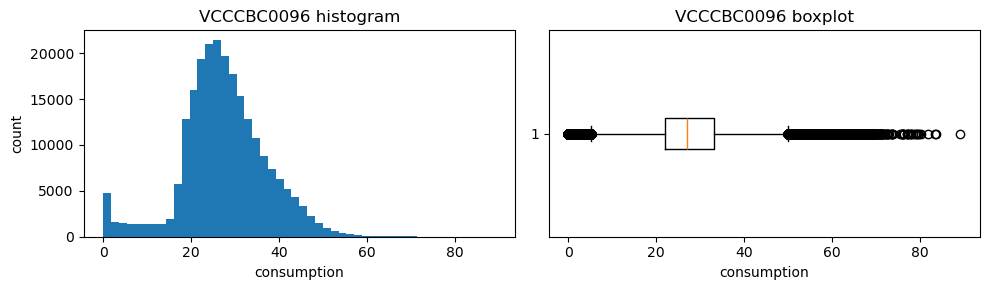

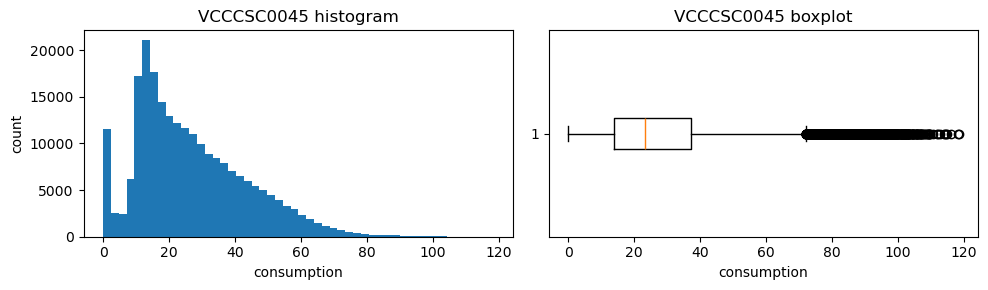

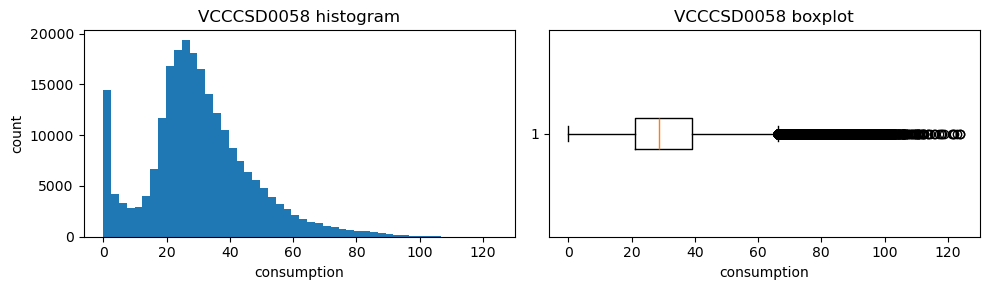

In [10]:
# Generate plots for every shortlisted NMI.
for nmi in NMI_shortlist:
    plot_distribution(nmi)
    plt.show()
    plt.close()